# Stock Analysis Pipeline — End-to-End Research Notebook

This notebook runs the full pipeline interactively:

1. **Load** cached SEC filings with sentiment scores (`data/fetched/processed_filings.xlsx`)
2. **Engineer features** (fundamentals, sentiment momentum, technical indicators)
3. **Walk-forward validation** (purged XGBoost, no look-ahead bias)
4. **Portfolio backtest** vs S&P 500 and universe benchmark

> Outputs are written to `*_notebook.xlsx` files so existing pipeline caches are untouched.

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\honza\Desktop\projects\stock-analysis


## 1. Load processed filings

One row per 10-Q filing: ticker, filing date, MD&A sentiment score, revenue and net income.

In [2]:
processed = pd.read_excel("data/fetched/processed_filings.xlsx")
print(f"{len(processed)} processed filings | {processed['ticker'].nunique()} tickers")
processed[["ticker", "filing_date", "sentiment_score", "revenue", "net_income"]].head()

1160 processed filings | 50 tickers


,ticker,filing_date,sentiment_score,revenue,net_income
0,AAPL,2026-01-30,0.2000,NaN,"42,097,000,000.0000"
1,AAPL,2025-08-01,0.2000,NaN,"23,434,000,000.0000"
2,AAPL,2025-05-02,0.2000,NaN,"24,780,000,000.0000"
3,AAPL,2025-01-31,0.2000,NaN,"36,330,000,000.0000"
4,AAPL,2024-08-02,0.2000,NaN,"21,448,000,000.0000"


## 2. Feature engineering

- `revenue_growth`, `net_margin` — fundamentals (only between consecutive quarterly filings)
- `sentiment_change` (+ triplet deltas) — quarter-over-quarter sentiment momentum
- `rsi`, `macd`, `volatility` — daily TA matched to each filing's last trading day on or before the filing date
- `next_quarter_return` — 90-day forward return from the filing date (the target)

In [3]:
from src.feature_eng import engineer_features

features = engineer_features(
    processed.copy(),
    output_path="data/fetched/features_notebook.xlsx",
    horizon_days=90,
    include_ta=True,
)
print(f"{len(features)} feature rows | {features['ticker'].nunique()} tickers")
features.head()

Fetching market data for all relevant tickers...


Fetching Market Data:   0%|          | 0/50 [00:00<?, ?it/s]

Calculating Technical indicators (RSI, MACD, Volatility)...


Engineering TA Features:   0%|          | 0/50 [00:00<?, ?it/s]

Calculating 90-Day Returns:   0%|          | 0/1160 [00:00<?, ?it/s]


Applying granular cleaning to 1160 historical rows...
43 tickers / 572 rows remaining for training.
Engineered features saved to data/fetched/features_notebook.xlsx
572 feature rows | 43 tickers


,ticker,filing_date,revenue,net_income,sentiment_score,revenue_growth,net_margin,sentiment_change,next_quarter_return,sentiment_pos,sentiment_neg,sentiment_neu,sentiment_pos_change,sentiment_neg_change,sentiment_neu_change,rsi,macd,volatility
0,CSCO,2018-05-22,"12,463,000,000.0000","2,691,000,000.0000",0.0000,0.0485,0.2159,0.0000,0.0671,NaN,NaN,NaN,NaN,NaN,NaN,44.4052,0.0583,0.0098
1,COST,2018-06-07,"32,361,000,000.0000","762,000,000.0000",0.0000,-0.0192,0.0235,0.0000,0.1660,NaN,NaN,NaN,NaN,NaN,NaN,64.8593,1.3714,0.0173
2,PEP,2018-07-10,"16,090,000,000.0000","1,830,000,000.0000",0.2000,0.2808,0.1137,0.0000,-0.0337,NaN,NaN,NaN,NaN,NaN,NaN,72.1437,1.6565,0.0300
3,NFLX,2018-07-18,"3,907,270,000.0000","384,349,000.0000",0.0000,0.0558,0.0984,0.0000,-0.0766,NaN,NaN,NaN,NaN,NaN,NaN,42.7233,0.5074,0.0282
4,AXP,2018-07-24,"6,194,000,000.0000","1,623,000,000.0000",0.0000,0.0518,0.2620,0.0000,0.0312,NaN,NaN,NaN,NaN,NaN,NaN,58.8403,0.6720,0.0091


### Quick sanity checks

,sentiment_score,sentiment_change,revenue_growth,net_margin,rsi,macd,volatility
count,572.0000,572.0000,572.0000,572.0000,572.0000,572.0000,572.0000
mean,0.1472,0.0108,0.0958,0.2099,53.6104,0.8421,0.0316
std,0.3173,0.1464,0.8116,3.4882,13.5498,4.0428,0.0200
min,-0.6000,-0.7000,-1.8226,-63.4902,17.6225,-22.2139,0.0060
25%,0.0000,0.0000,-0.0070,0.0967,43.5639,-0.4927,0.0174
50%,0.0000,0.0000,0.0297,0.2187,55.0202,0.5266,0.0259
75%,0.3000,0.0000,0.0823,0.3011,63.6840,1.9419,0.0403
max,0.8000,0.7000,11.9250,51.8871,90.9758,26.8186,0.1449


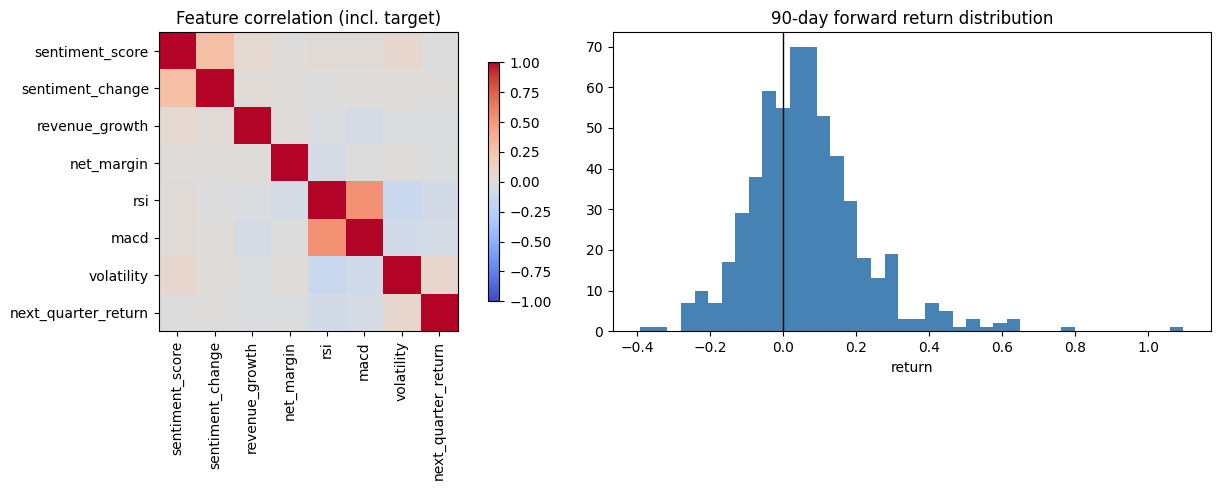

In [4]:
model_cols = ["sentiment_score", "sentiment_change", "revenue_growth", "net_margin", "rsi", "macd", "volatility"]
display(features[model_cols].describe())

corr = features[model_cols + ["next_quarter_return"]].corr()
labels = list(corr.columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=90)
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels)
axes[0].set_title("Feature correlation (incl. target)")
fig.colorbar(im, ax=axes[0], shrink=0.8)

axes[1].hist(features["next_quarter_return"].dropna(), bins=40, color="steelblue")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("90-day forward return distribution")
axes[1].set_xlabel("return")
plt.tight_layout()
plt.show()

## 3. Walk-forward validation

For each quarter starting 2021: train XGBoost on all *earlier* quarters whose 90-day outcome window has fully closed (purging), then predict the current quarter out-of-sample.

In [5]:
from src.model import run_walk_forward_predictions

predictions = run_walk_forward_predictions(
    features.copy(),
    output_path="data/fetched/predictions_notebook.xlsx",
    start_year=2021,
    lookahead_days=90,
)
predictions.head()

Starting Robust Walk-Forward (Purging Overlaps)...


Walk-Forward Quarters:   0%|          | 0/21 [00:00<?, ?it/s]

C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_return'] = model.predict(X_test.values)
C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_return'] = model.predict(X_test.values)
C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_return'] = model.predict(X_test.values)
C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_return'] = model.predict(X_test.values)
C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_return'] = model.predict(X_test.values)
C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_return'] = model.predict(X_test.values)
C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_return'] = model.predict(X_test.values)
C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_return'] = model.predict(X_test.values)
C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_return'] = model.predict(X_test.values)
C:\Users\honza\Desktop\projects\stock-analysis\src\model.py:145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_return'] = model.predict(X_test.values)


Calculating Final Purged CV Score...


Purged CV MSE: 0.037921 (std: 0.003515)
Strategy metrics saved to data/fetched/metrics_notebook.xlsx
Walk-forward predictions saved to data/fetched/predictions_notebook.xlsx


,ticker,filing_date,quarter,next_quarter_return,predicted_return
0,MSFT,2021-01-26,2021Q1,0.1284,0.0751
1,LRCX,2021-02-02,2021Q1,0.1989,0.0713
2,CSCO,2021-02-16,2021Q1,0.1464,0.0249
3,COST,2021-03-10,2021Q1,0.1750,0.0666
4,ORCL,2021-03-11,2021Q1,0.2592,0.0524


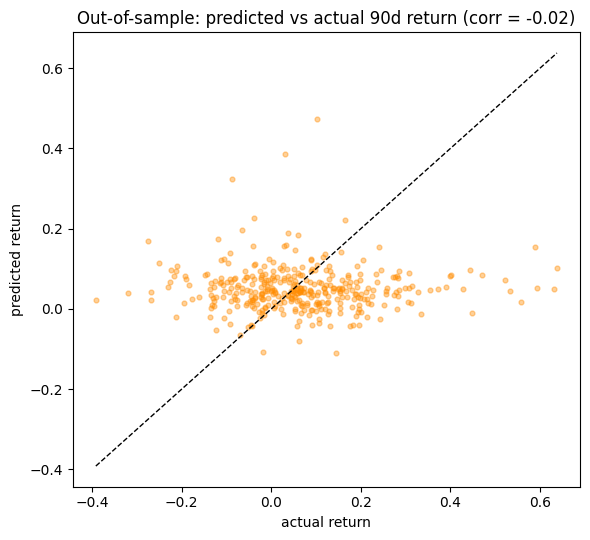

In [6]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(predictions["next_quarter_return"], predictions["predicted_return"], s=12, alpha=0.4, color="darkorange")
lims = [predictions["next_quarter_return"].min(), predictions["next_quarter_return"].max()]
ax.plot(lims, lims, "k--", lw=1)
r = predictions["next_quarter_return"].corr(predictions["predicted_return"])
ax.set_title(f"Out-of-sample: predicted vs actual 90d return (corr = {r:.2f})")
ax.set_xlabel("actual return")
ax.set_ylabel("predicted return")
plt.tight_layout()
plt.show()

## 4. Portfolio backtest

Quarterly rebalance: hold the top 10 tickers by predicted return (positive predictions only), weighted by prediction size. Benchmarks: S&P 500 and equal-weight buy & hold of the whole universe.

In [7]:
from src.backtester import simulate_portfolio

backtest = simulate_portfolio(
    predictions.copy(),
    output_path="data/fetched/backtest_notebook.xlsx",
    initial_capital=100.0,
    frequency="Q",
    top_n=10,
)
backtest.head()

Fetching daily price history for 40 tickers...


--- Backtest Initializing (Quarterly) ---


Simulating Daily:   0%|          | 0/1337 [00:00<?, ?it/s]

Calculating benchmarks for comparison...



Daily Backtest results saved to data/fetched/backtest_notebook.xlsx


,date,portfolio_value,quarterly_return,selection,spy_value,universe_bh_value
0,2021-01-04,100.0000,-0.0000,"MSFT, LRCX, COST, ORCL, CSCO",100.0000,100.0000
1,2021-01-05,100.3876,0.0039,"MSFT, LRCX, COST, ORCL, CSCO",100.7083,101.0877
2,2021-01-06,99.5099,-0.0087,"MSFT, LRCX, COST, ORCL, CSCO",101.2833,101.9922
3,2021-01-07,101.2754,0.0177,"MSFT, LRCX, COST, ORCL, CSCO",102.7871,103.8536
4,2021-01-08,101.0044,-0.0027,"MSFT, LRCX, COST, ORCL, CSCO",103.3516,104.2857


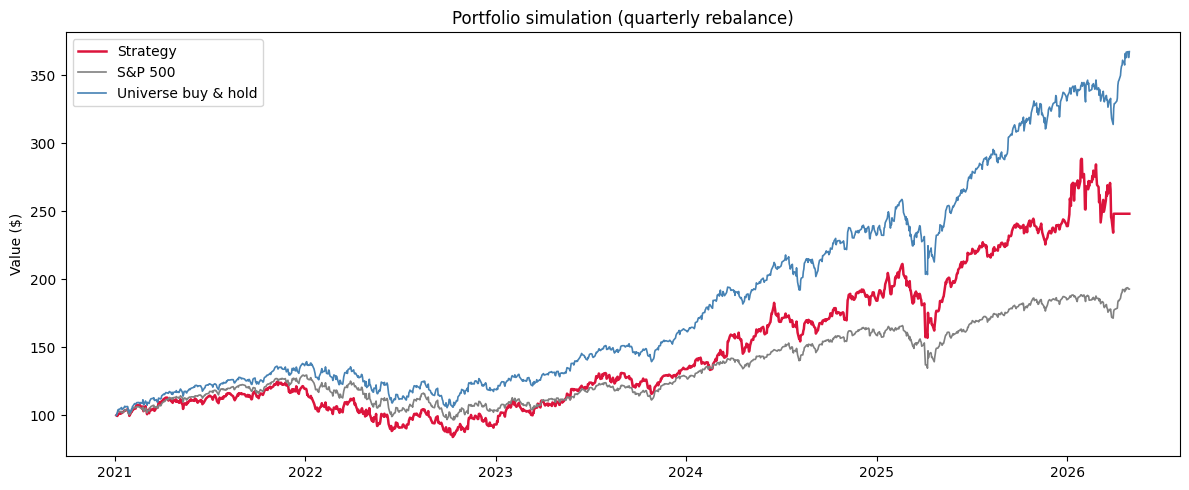

,Strategy,S&P 500,Universe B&H
total_return,1.4823,0.9283,2.6745
cagr,0.1865,0.1314,0.2773
max_drawdown,-0.3256,-0.2543,-0.2426


In [8]:
bt = backtest.set_index("date")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(bt.index, bt["portfolio_value"], label="Strategy", color="crimson", lw=1.8)
ax.plot(bt.index, bt["spy_value"], label="S&P 500", color="gray", lw=1.2)
ax.plot(bt.index, bt["universe_bh_value"], label="Universe buy & hold", color="steelblue", lw=1.2)
ax.set_title("Portfolio simulation (quarterly rebalance)")
ax.set_ylabel("Value ($)")
ax.legend()
plt.tight_layout()
plt.show()

days = (bt.index[-1] - bt.index[0]).days

def perf(series):
    total = series.iloc[-1] / series.iloc[0] - 1
    cagr = (series.iloc[-1] / series.iloc[0]) ** (365.25 / days) - 1
    max_dd = (series / series.cummax() - 1).min()
    return pd.Series({"total_return": total, "cagr": cagr, "max_drawdown": max_dd})

pd.DataFrame({
    "Strategy": perf(bt["portfolio_value"]),
    "S&P 500": perf(bt["spy_value"]),
    "Universe B&H": perf(bt["universe_bh_value"]),
})